<a href="https://colab.research.google.com/github/tuankhoin/CO3057-Computer-Vision/blob/main/Week_6_Multiview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

Ho Chi Minh University of Technology (HCMUT)

CO3057 - Digital Image Processing and Computer Vision

# Week 6 - Multiview models and method

<img src='https://media.tenor.com/2TohLIAkiN4AAAAM/spider-filter.gif'/>

## Learning Outcomes
- Explain the cues available for depth perception in single-view and multi-view images
- Compute depth from disparity
- Explain how a standard stereo depth algorithm works
- Explain machine-learning approaches to single-view depth
- Explain the unknowns that must be solved in a multi-view depth problem
- Explain two-view (epipolar geometry) and how it constrains the solution to this problem
- Define a "calibrated" camera and explain what is represented in a camera matrix

---
# 1. Ways to identify Depth
---
## Perspective

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/perspective.png?raw=true)

## Texture

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/texture.png?raw=true)

## Object Position and Occlusion

Question: How can you know that this label is lying on top of another label?
![](https://raw.githubusercontent.com/tuankhoin/CO3057-Computer-Vision/refs/heads/main/assets/w6detem.png)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/object_position.png?raw=true)

## Object Knowledge
- With objects that we know about, we can interpret the depth of the image.

Example: Pisa Tower

![](https://i.imgur.com/xrDXF9i_d.webp?maxwidth=520&shape=thumb&fidelity=high)

You already knew what it is:

![](https://images.meme-arsenal.com/d0d7e306eeb8eab7448ae5dc4cae7b24.jpg)


## Binocular Stereo
- Add some distance between color channels to create the feeling of depth

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/binocular_stereo.png?raw=true)

## Motion Parallax
The closer an object is to you, the faster-moving it will feels like.

![](https://www.appstate.edu/~steelekm/classes/psy3215/MonocularDepth/motionparallax.jpg)

## Summary
- 2D images contain a variety of information for depth perception
- Cues available in a single view include perspective, texture, and object cues
- More accurate depth information can be obtained by **combining multiple views** (**stereo**, **motion**)

---
# 2. Stereo
---

Stereo pair: images from two cameras with a **horizontal shift** in camera position

![](https://raw.githubusercontent.com/travisddavies/computer_vision_notes/refs/heads/main/Images/depth_from_stereo.png?raw=true)

## Depth from Stereo
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/window_matching_resuls.png?raw=true)

![](https://raw.githubusercontent.com/travisddavies/computer_vision_notes/refs/heads/main/Images/depth_from_stereo%201.png)

Assume:
- Image planes of cameras are parallel to each other and to the baseline $B$
- Camera centres are at the same height
- Focal lengths $f$ are the same

Goal: find $z$ (**depth**/how far away is object)


## Solve for $z$:
$$
\frac{z}{B} = \frac{f}{x-x'}
\;\;\;\;\rightarrow\;\;\;\;
z = \frac{fB}{x-x'}
$$
- Distance $z$ is inversely proportional to disparity $x-x'$

## Basic Stereo Matching Algorithm

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/abe_lincoln.png?raw=true)

- For each pixel $x$ in one image
	- Scan a horizontal line in the other image, find best match $x'$
	- Compute disparity $x-x'$
  - Compute depth $z = \frac{fB}{x-x'}$

## Finding best match
- Set a window size, with the chosen pixel in the center.
- To compare 2 pixels, check wether the pixels in their windows match
- Usually use Normalized Cross Correlation, as Squared Errors cannot handle different lightings.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/basic_stereo_matching2.png?raw=true)

## Effect of Window Size

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/effect_window_size.png?raw=true)

- Smaller window = finer detail, but more noise
- Larger window = smoother depth, but lacking detail
## Hard cases
- Repeated patterns

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/paris.png?raw=true)

- Reflective objects.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/reflective_objects.png?raw=true)

## Additional Constraints?
- Individual matches are often ambiguous (no additional info)
- However, the set of matches should obey additional constraints (if possible. Does not always apply):
	- **Uniqueness**: a point in one view has no more than one match in the other view
	- **Ordering**: corresponding points should be in the same order in both views
	- **Smoothness**: disparity values should change smoothly (for the most part)

## Rectification
What if the image planes are not parallel?
- **Rectification** finds projective transform that maps each image to the same plane

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/rectification.png?raw=true)

## Summary
- Stereo depth is computed from disparity (difference in position of points in two views of a scene)
- Difficult to solve in practice because individual point matches are ambiguous
- Solution generally involves additional constraints (e.g., smoothness)

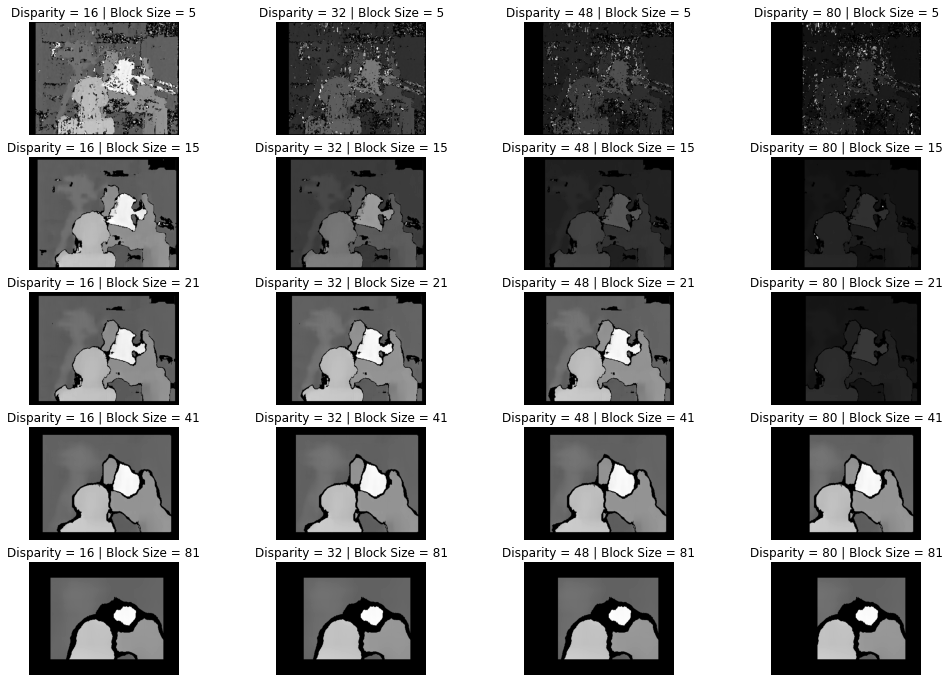

In [ ]:
imgL= cv2.imread(path + "tsukuba_l.png",cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread(path + "tsukuba_r.png",cv2.IMREAD_GRAYSCALE)

# Grid search is always good for this type of exercises
nd,bs = np.meshgrid([16,32,48,80],[5,15,21,41,81])
_,ax = plt.subplots(*nd.shape, figsize=(17,12))

for (x,y),n in np.ndenumerate(nd):
    # Again, just copy and pasting here lmao
    stereoBM = cv2.StereoBM_create(numDisparities=n, blockSize=bs[x,y])
    # Compute the disparity image
    disparityBM = stereoBM.compute(imgL,imgR)
    # Scale the pixel values to between 0-255 (Or you can normalized to [0,1])
    min = disparityBM.min()
    max = disparityBM.max()
    disparityBM = ((disparityBM - min) / (max - min)*255).astype(np.uint8)

    ax[x,y].imshow(disparityBM,'gray')
    ax[x,y].set_title(f'Disparity = {n} | Block Size = {bs[x,y]}')
    ax[x,y].axis('off')
plt.show()






---
# 3. Single-View Depth
---
## Depth from Single Images
We can get depths from a single image with deep/machine learning. Example:
- Building locations (e.g. occlusions)
- Lines, the sky,...

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/depth_from_single_images.png?raw=true)

## Supervised Depth Classification
- Treat depth estimation as a **classification** task: For each pixel in image, predict distance from camera
- Train on images with annotated depth maps

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/supervised_depth_classification.png?raw=true)

## Loss Function?
- Images may have a very large range of depths ⇒ **log(depth)** may work better than absolute depth as loss function.
- Mean depth of scenes can vary widely (e.g., room vs. stadium) ⇒ scaling/normalizing the loss function so that it is similar for different scenes

## Depth from Disparity
Annotated depth maps requires LIDAR → Expensive

Alternative: train on **stereo image pairs**

- Input: one image from a stereo pair (e.g., left)
- Learn to predict the **disparity map** that will produce the other image (e.g., right)
- Distance from camera to surfaces can be computed from the disparity map

- Loss function can be sum of:
	- Appearance loss (difference between original and predicted image)
	- Disparity smoothness loss
	- Left-right consistency loss (difference disparity maps)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/disparity_results.png?raw=true)



## Summary
- Machine learning methods can be trained to estimate depth from single images
- Advantages:
	- Does not require multiple views / stereo camera
- Disadvantages:
	- "Blurry" depth at object edges (but can be combined with edge maps for better results)
	- Models may not generalise well to new contexts

- 2D images provide multiple cues for 3D depth (single-image and multi-image cues)
- It is possible to compute depth from single images, but **more accurate depth measurements** can be obtained from **multiple views (e.g., stereo)**

---
# 4. Multi-View Problem
---
- Stereo setups assumes focal length (f) is known ⇒ Not always the case!
- **Multi-view problem** will solve for:
	- **Extrinsics** (Camera motion) - what is the transform (camera translation + rotation) that relates the two views?
	- **Intrinsics** (Camera parameters e.g., focal length), if not known
	- Original point's **3D position** - given corresponding image points ($x, x'$) in the two views.

---
# 5. Camera Calibration
---

- We know how to compute 3D $P = (x,y,z)$ from image plane $xy$ when the imaging parameters like $f$, $C_i$ are known
- Usually, these parameters are unknown

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/camera_calibration.png?raw=true)

## Camera Parameters
- **Intrinsic parameters**: camera parameters related to image formation (focal length, optical centre, lens distortion)
- **Extrinsic parameters**: camera pose (location and orientation) relative to the world

Camera calibration is a process to find these parameters.

## Camera Calibration Method
Camera calibration requires a calibration target
- A planar surface with known pattern that is easily detected/tracked by feature detection methods
- Common choices: checkerboard, squares, circles, CharuCo

Steps
1. Take multiple photos (or a video) of the calibration target **in many different poses**
2. **Solve** for intrinsic and extrinsic parameters

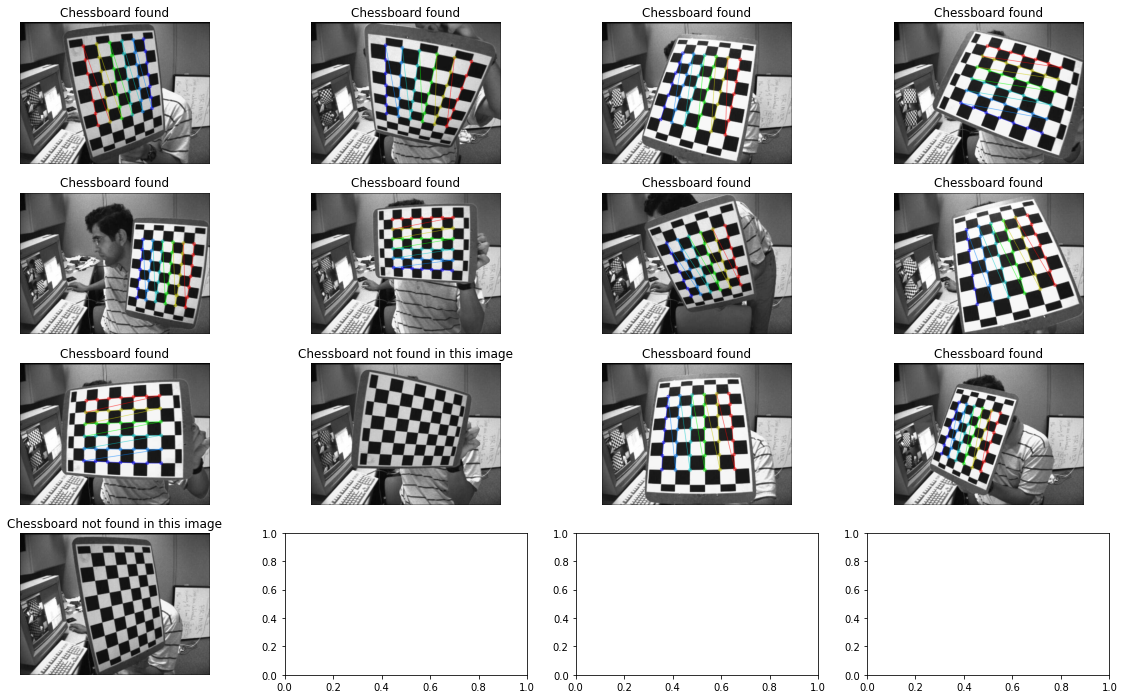

In [ ]:
# Define the grid we are trying to find,
# In this case we use 7x6 grid (see the plot show).
grid_size = (7,6)

# Arrays to store object points and image points
obj_points = [] # 3d point in real world space
img_points = [] # 2d points in image plane.

# Prepare a grid that allows all object points to be stored orderly,
# like (0,0,0), (1,0,0),....,(6,5,0)
objp = np.zeros((np.prod(grid_size),3), np.float32)
objp[:,:2] = np.mgrid[0:grid_size[0],0:grid_size[1]].T.reshape(-1,2)

# Set the termination criteria for the corner sub-pixel algorithm
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
# Here, we care about both accuracy and number of iterations,
# stop the algorithm iteration if specified accuracy (0.001),
# stop the algorithm after the specified number of iterations (30).

img_paths = glob.glob(path+'/chessboard/*')

# Deal with multiple images iteratively using glob
_,ax = plt.subplots(len(img_paths)//4 + int(bool(len(img_paths)%4)),4,figsize=(20,12))
for i,name in enumerate(img_paths):
    img = cv2.imread(name)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, grid_size, None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        obj_points.append(objp)
        img_points.append(corners)

        # Refine corner location based on criteria
        corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

        # Draw and display the grid on the image
        cv2.drawChessboardCorners(img, grid_size, corners2, ret)

        ax[i//4,i%4].imshow(img, cmap='gray')
        ax[i//4,i%4].set_title('Chessboard found')
        ax[i//4,i%4].axis('off')
    else:
        ax[i//4,i%4].imshow(img, cmap='gray')
        ax[i//4,i%4].set_title('Chessboard not found in this image')
        ax[i//4,i%4].axis('off')

plt.show()

In [ ]:
# ret: a flag
# mtx: camera matrix
# dist: distortion coefficients
# rvecs: rotation vectors
# tvecs: translation vectors

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(obj_points, img_points, gray.shape[::-1], None, None)

# print the camera matrix
print(mtx)

[[534.07088323   0.         341.53407616]
 [  0.         534.11914507 232.94565306]
 [  0.           0.           1.        ]]


## Homogeneous Coordinates

When converting between world and image points, it is often convenient to use **homogeneous** (or **projective**) coordinates
- Image points are represented with 3 values ($x_i,y_i,z_i$)
- The third value can be thought of as the distance to the image plane
- $x, y$ values scales with $z$.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/homogeneous_coords.png?raw=true)

## Projection Model (Fixed camera position)
- The pinhole projection model can be represented as a matrix in homogeneous coordinates:

$$
\underbrace{
\begin{bmatrix}
x_i \\
y_i \\
z_i
\end{bmatrix}
}_{\text{Image coordinates}}
=
\underbrace{
\begin{bmatrix}
f_x & 0 & c_x & 0 \\
0 & f_y & c_y & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
}_{\text{Camera Intrinsics } K}
\underbrace{
\begin{bmatrix}
x \\
y \\
z \\
1
\end{bmatrix}
}_{\text{World coordinates}}
$$

Expanding the matrix multiplication:

$$
\begin{aligned}
x_i &= f_x x + c_x z \\
y_i &= f_y y + c_y z \\
z_i &= z
\end{aligned}
$$

$$
(f_x, f_y) = \text{focal length} \ \ \ \ \ (c_x, c_y) = \text{optical centre}
$$

## Projection Model (Multiple/Moving camera)
- Relationship between points in the world and points in the image:

$$
\underbrace{
\begin{bmatrix}
x_i \\
y_i \\
1
\end{bmatrix}
}_{\text{Image coordinates}}
=
\underbrace{
\begin{bmatrix}
f_x & 0 & c_x & 0 \\
0 & f_y & c_y & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
}_{\text{Camera Intrinsics } K}
\underbrace{
\begin{bmatrix}
R_{3 \times 3} | T_{3 \times 1}
\end{bmatrix}_{4 \times 4}
}_{\text{Extrinsic parameters}}
\underbrace{
\begin{bmatrix}
x \\
y \\
0 \\
1
\end{bmatrix}
}_{\text{World coordinates}}
$$

For simplicity, assume the calibration target lies on the plane \(z = 0\). The projection then reduces to a homography:

$$
\underbrace{
\begin{bmatrix}
x_i \\
y_i \\
1
\end{bmatrix}
}_{\text{Image coordinates}}
=
\underbrace{H}_{\text{Homography}}
\underbrace{
\begin{bmatrix}
x \\
y \\
0 \\
1
\end{bmatrix}
}_{\text{Planar world coordinates}}
$$

$H$ we can think of as the combination of the camera matrix $K$ and the rotation $R$ + translation $T$ matrix


## Calibration Algorithm
- Multiple images → Linear equations
- Solve for: $H$ or $(R,T,K)$
- Estimate distortion parameters (different formulas for different distortion models)
- Iterate to refine parameters (bundle adjustment)

## Alternative Methods to Texture-based Calibration
- Calibration using planar surfaces in the world
	- Advantage: no need for a special calibration target
	- Disadvantage: more difficult to detect/track keypoints, may introduce errors
- Look up camera parameters from manufacturer specifications
	- Advantage: no computation!
	- Disadvantage: only for cameras with fixed focal length (sometimes the manufacturers get it wrong as well)
- Calibration using Human Pose (we are trying to do that!)

## Fact
Calibration is required for application that involve accurate mapping between world and image points
- augmented/virtual reality (AR/VR)
- motion capture
- visual odometry


---
# 6. Epipolar Geometry - Basics
---
## Two-View Problem
![](https://raw.githubusercontent.com/travisddavies/computer_vision_notes/refs/heads/main/Images/two_view_problem.png?raw=true)

What is the camera transform (translation + rotation) that relates these two views?

## Formulation

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/estimating_camera_transform.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/epipolar_geometry_notation.png?raw=true)

## Examples of Epipolar Lines

Case 1: Where does the Epipolar lines meet?

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/epipolar_lines.png?raw=true)

Case 2: The lines will not meet. Why?

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/example_horizontal_motion.png?raw=true)

Case 3: Forward Motion

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/example_forward_motion3.png?raw=true)

## Summary
- Epipolar geometry describes relations between points in two views
- A point in one image lies along an **epipolar line** in the other image
- Epipolar lines in an image meet at a point called the **epipole** - the projection of one camera in the other image






---
# 7. More Matrices & Maths
---

## Essential Matrix $E$

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/epipolar_constraint.png?raw=true)

- $E\hat{x}$ is the epipolar line $l'$
- $E^T \hat{x}'$ is the epipolar line $l$
- $Ee'=0$ gives the epipole $e'$ in the right image (projection of left camera's centre $C$)
- $E^Te=0$ gives the epipole $e$ in the left image (projection of right camera's centre $C'$)
- $E$ has 5 degrees of freedom (rotation 3 + translation 2, missing a scaling factor)

## Fundamental Matrix $F$
If the camera parameters are unknown (uncalibrated cameras) → Not enough to find $E$
- Can define a similar relationship using the unknown $K$ and $K'$:
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/fundamental_matrix.png?raw=true)

- $Fx$ is the epipolar line $l'$, $F^Tx'$ is the epipolar line $l$
- $F$ has 7 degrees of freedom (3x3 matrix, but it has an unknown scaling factor and $Det(F)=0$, which removes 2)

## Solving for $F$: 8-point algorithm
Match pairs of points across views and find matrix $F$ that explains the correspondences

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/solving_for_F.png?raw=true)

- Requires 8 matching points (**One more** than the 7 degrees of freedom)
- Solve for $F$ as a linear system of equations

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/8pontmatrix.png?raw=true)

- Additional steps (SVD = singular value decomposition) to ensure that $F$ has the correct form

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/solving_for_F2.png?raw=true)

## Limitations
- System is only solved up to a scaling factor, **need at least one known distance** to solve for real-world positions
- Degenerate cases: can't solve if the system has too few degrees of freedom
	- Points in the world are all coplanar
	- Camera translation = 0 (just rotation)

## Summary
- Epipolar geometry describes how a point in 3D space is imaged through a pair of cameras
- Essential and Fundamental matrices map point in one image to a line (epipolar line) in the other image
- Typically, use feature detection to find matching points in the two views, then solve for Fundamental matrix (e.g., using RANSAC)

| Matrix | Elements (formula form) | Geometric meaning / what it encodes | Other ways to obtain it | How to extract elements | Required conditions / assumptions |
|------|------|------|------|------|------|
| **Intrinsic matrix (K)** | $\begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$ | Camera internal parameters: focal length, pixel scaling, principal point | Camera calibration (Zhang's method) | Directly estimated from calibration images | Assumes **pinhole camera model** |
| **Extrinsic matrix $[R \mid T]$** | Rotation $R$ and translation $T$ | Camera pose relative to world coordinates | Estimated via **PnP** algorithms | Extract directly from pose estimation | Requires known **3D–2D correspondences** |
| **Projection matrix (P)** | $P = K[R \mid T]$ | Full mapping from **3D world point → image pixel** | Estimated using **DLT** from 3D–2D correspondences | Decompose with **RQ decomposition** to recover $K$, $R$, $T$ | Requires calibrated camera model |
| **Essential matrix (E)** | $E = [t]_\times R$ | Relative motion between two cameras (rotation + translation direction) | $E = K^T F K$ or 6 matching correspondences | **SVD decomposition** gives $R$ and $t$ (four possible solutions) | Cameras must be **calibrated** |
| **Fundamental matrix (F)** | Relates corresponding image points | Epipolar geometry between two views (image–image constraint) | Estimated via **8-point algorithm** or **RANSAC** | Cannot extract $R,T$ without calibration | Works for **uncalibrated cameras** |
| **Homography (H)** | $H = K(R - \frac{t n^T}{d})K^{-1}$ | Mapping between two images of the **same plane** | Estimated from **4+ planar correspondences** | Can be decomposed to estimate $R,T,n$ (up to scale) | Scene must be **planar** or camera motion must be **pure rotation** |

### Notation

- **Skew-symmetric matrix $[t]_\times$**

  For a translation vector

  $$
  t =
  \begin{bmatrix}
  t_x \\
  t_y \\
  t_z
  \end{bmatrix}
  $$

  the skew-symmetric matrix is

  $$
  [t]_\times =
  \begin{bmatrix}
  0 & -t_z & t_y \\
  t_z & 0 & -t_x \\
  -t_y & t_x & 0
  \end{bmatrix}
  $$

  This matrix converts the **cross product** into matrix multiplication:

  $$
  [t]_\times v = t \times v
  $$

- **Plane normal $n$**

  $$
  n =
  \begin{bmatrix}
  n_x \\
  n_y \\
  n_z
  \end{bmatrix}
  $$

  The vector perpendicular to a planar surface.  
  It describes the **orientation of the plane in 3D space**.

- **Plane distance $d$**

  $d$ represents the **distance from the camera center to the plane** along the normal direction.

  In plane equations:

  $$
  n^T X = d
  $$

  where \(X\) is a 3D point on the plane.

---
# 8. Applications
---

## Application: GPS Location Refinement
Problem: GPS is not accurate within 10 meters.

Algorithm:
- Detect ASIFT (affine-invariant SIFT) keypoints in each image → match
- Use RANSAC to find Fundamental matrix ($F$) that relates the two views, and remove outlier matches
- Compute Essential matrix ($E$) from $F$ using known camera matrices $K$
- Decompose $E$ into rotation $R$ and translation $T$ between cameras

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/refining_gps_location.png?raw=true)

## Beyond two-view geometry
![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/mocap-display.gif?raw=true)

![](https://github.com/tuankhoin/CO3057-Computer-Vision/blob/main/assets/mocap-display2.gif?raw=true)

3D Reconstruction:
- Structure from motion: Point cloud/Mesh from multiple 2D images
- Simultaneous localisation and mapping (SLAM) - Know where you are globally
- Visual Odometry - Know how much you have moved
- 3D Pose Estimation (Motion capture)
- Snapchat Filters

---
# Exercise
---

Consider the images shown below. Describe two cues that can be used to infer depth from each image and explain what can be computed from each cue.

<img style="float: ;" src="https://raw.githubusercontent.com/saraao/COMP90086_image/main/room.jpg" width=400>

Answer:

- Perspective (lines on floor, walls) - gives relative depth on surface.
- Occlusion (e.g., chairs occlude table) - gives rank order of objects, but not actual depth.
- Height in image (e.g., chairs) - gives rank order of objects, but not actual depth.
- Real world size of known objects (e.g., chairs) - could be used to compute distance if camera is calibrated.

<img style="float: ;" src="https://raw.githubusercontent.com/saraao/COMP90086_image/main/lake.jpg" width=400>

Answer:

- Height in image (e.g., boats) - gives rank order of objects, but not actual depth.
- Texture (e.g., water) - could be used to compute relative distance or surface normal.
- Real world size of known objects (e.g., boats) - could be used to compute distance if camera is calibrated.